### Import and Connect

In [10]:
import duckdb
conn = duckdb.connect('algory.duckdb')

def load_table(name):
    return conn.sql(f"SELECT * FROM {name}").df()

##### Trades

In [11]:
trades = load_table("trades")
display(trades)

,trade_id,timestamp,strategy,symbol,side,quantity,price
0,1770853181011067,2026-02-11 18:39:41.011068,pairs,MSFT,BUY,32.153393,97.118374
1,1770853181158644,2026-02-11 18:39:41.158644,cluster_v2,GOOG,BUY,0.108038,176.306871
2,1770853181526450,2026-02-11 18:39:41.526450,momentum,GOOG,BUY,28.206942,177.261325
3,1770853182042682,2026-02-11 18:39:42.042682,mean_reversion,AAPL,BUY,5.000000,227.834405
4,1770853182042682,2026-02-11 18:39:42.042682,mean_reversion,AMZN,BUY,5.000000,266.157023
...,...,...,...,...,...,...,...
577,1770853322183372,2026-02-11 18:42:02.183372,mean_reversion,NVDA,SELL,-5.000000,245.469805
578,1770853322183372,2026-02-11 18:42:02.183372,mean_reversion,TSLA,SELL,-5.000000,189.000446
579,1770853322183372,2026-02-11 18:42:02.183372,mean_reversion,JPM,SELL,-5.000000,163.407663
580,1770853322183372,2026-02-11 18:42:02.183372,mean_reversion,NFLX,SELL,-5.000000,180.754543


##### Portfolio History

In [12]:
portfolio_history = load_table("portfolio_history")
display(portfolio_history)

,timestamp,total_value,total_cash,total_positions
0,2026-02-11 18:39:43.034627,99756.664040,86921.909919,9
1,2026-02-11 18:39:45.078575,99838.007642,82006.052153,11
2,2026-02-11 18:39:47.183829,100011.083619,77473.687842,10
3,2026-02-11 18:39:49.203203,99629.298029,68110.940112,10
4,2026-02-11 18:39:51.215602,99849.875085,55770.119341,10
...,...,...,...,...
63,2026-02-11 18:41:53.681567,106290.584432,-109814.446612,12
64,2026-02-11 18:41:55.769742,107504.830053,-107890.810202,12
65,2026-02-11 18:41:57.914696,112897.899018,-107434.723973,12
66,2026-02-11 18:42:00.047935,116504.401686,-107560.352755,12


##### Strategy History

In [13]:
strategy_history = load_table("strategy_history")
display(strategy_history)

,timestamp,strategy,strategy_value,cash,exposure,n_positions
0,2026-02-11 18:39:43.034627,cluster_v2,24999.667835,24980.952236,18.715599,1
1,2026-02-11 18:39:43.034627,mean_reversion,24991.636074,20063.642981,4927.993093,7
2,2026-02-11 18:39:43.034627,momentum,24886.354572,20000.000000,4886.354572,1
3,2026-02-11 18:39:43.034627,pairs,24879.005559,21877.314701,3001.690858,1
4,2026-02-11 18:39:45.078575,cluster_v2,25000.071368,24980.952236,19.119132,1
...,...,...,...,...,...,...
267,2026-02-11 18:42:00.047935,pairs,32964.020449,-113268.749430,146232.769879,12
268,2026-02-11 18:42:02.183372,cluster_v2,25000.867552,18133.466555,6867.400997,11
269,2026-02-11 18:42:02.183372,mean_reversion,31832.147902,21213.845812,10618.302090,11
270,2026-02-11 18:42:02.183372,momentum,27994.116858,-33175.722425,61169.839284,12


### Plot value over time

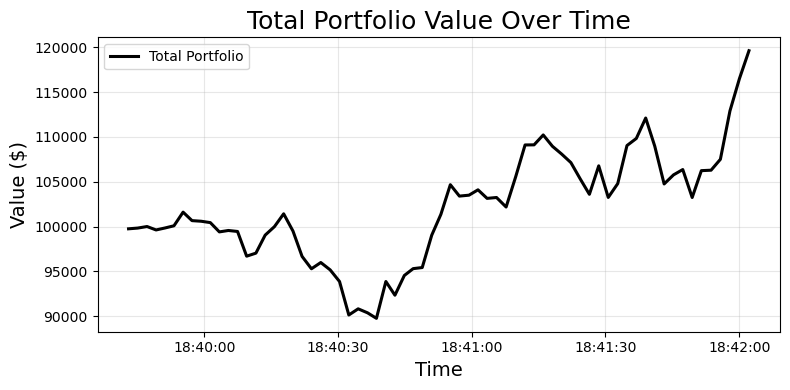

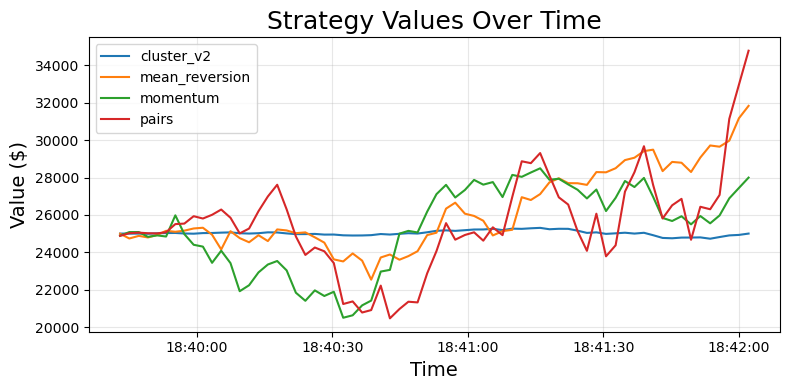

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_portfolio(portfolio: pd.DataFrame):
    plt.figure(figsize=(8, 4))

    plt.plot(
        pd.to_datetime(portfolio["timestamp"]),
        portfolio["total_value"],
        color="black",
        linewidth=2.2,
        label="Total Portfolio"
    )

    plt.title("Total Portfolio Value Over Time", fontsize=18)
    plt.xlabel("Time", fontsize=14)
    plt.ylabel("Value ($)", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_strategies(strategies: pd.DataFrame):
    plt.figure(figsize=(8, 4))

    for strat, df in strategies.groupby("strategy"):
        plt.plot(
            pd.to_datetime(df["timestamp"]),
            df["strategy_value"],
            label=strat  # auto-colored
        )

    plt.title("Strategy Values Over Time", fontsize=18)
    plt.xlabel("Time", fontsize=14)
    plt.ylabel("Value ($)", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_portfolio(portfolio_history)
plot_strategies(strategy_history)

### View portfolio metrics

In [15]:
from stats import getStats
import pandas as pd

##### Portfolio Stats

In [16]:
portfolio_stats = getStats.compute_portfolio_metrics(portfolio_history)
series = pd.Series(portfolio_stats)
display(series)

/Users/ryanvandeberghe/Documents/infrastructure/src/stats/getStats.py:61: RuntimeWarning: overflow encountered in scalar power
  cagr = (end_val / start_val) ** (1 / years) - 1


PnL                           1.990100e-01
Absolute PnL                  1.985258e+04
CAGR                                   inf
Max Drawdown                 -1.164938e-01
Sharpe Ratio                  5.598249e+02
Sortino Ratio                 6.039478e+02
Volatility                    7.910480e+01
Value at Risk (95%)          -2.901294e-02
Beta to Market                         NaN
Kurtosis                     -2.170967e-01
Average Trade Return          2.914445e-03
Median Trade Return           1.291751e-03
Win/Loss Ratio                1.392857e+00
Average Win / Average Loss    1.045540e+00
dtype: float64

##### Strategy Stats

In [17]:
strategy_stats = getStats.compute_strategy_metrics(strategy_history)
df = pd.DataFrame(strategy_stats)
display(df)

/Users/ryanvandeberghe/Documents/infrastructure/src/stats/getStats.py:195: RuntimeWarning: overflow encountered in scalar power
  cagr = (end_val / start_val) ** (1 / years) - 1
/Users/ryanvandeberghe/Documents/infrastructure/src/stats/getStats.py:195: RuntimeWarning: overflow encountered in scalar power
  cagr = (end_val / start_val) ** (1 / years) - 1
/Users/ryanvandeberghe/Documents/infrastructure/src/stats/getStats.py:195: RuntimeWarning: overflow encountered in scalar power
  cagr = (end_val / start_val) ** (1 / years) - 1


,cluster_v2,mean_reversion,momentum,pairs
PnL,0.000048,0.273712,0.124878,0.398051
Absolute PnL,1.199717,6840.511828,3107.762286,9903.103192
CAGR,53275.869836,inf,inf,inf
Max Drawdown,-0.022942,-0.109667,-0.210878,-0.258785
Sharpe Ratio,5.206378,715.563471,294.743831,499.826150
Sortino Ratio,4.257047,853.465497,292.011213,523.872319
Volatility,7.701239,81.326214,111.259086,186.199877
Value at Risk (95%),-0.003667,-0.031338,-0.041955,-0.076118
Beta to Market,NaN,NaN,NaN,NaN
Kurtosis,0.939613,1.239864,0.624169,0.568413


### Close DB

In [18]:
conn.close()